In [1]:
import pandas as pd

In [2]:
# Load the uploaded CSV file into a DataFrame
file_path = "apple_preprocessed_data.csv"
df = pd.read_csv(file_path)

# Show the first few rows to confirm successful load
df.head()

,Date,Close,High,Low,Open,Volume,RSI_14,MACD,MACD_Signal,MACD_Hist,Open_Growth,Close_Growth,High_Growth,Low_Growth,Volume_Growth,landmark,ground_truth
0,2/21/2014,16.445499,16.737307,16.425148,16.681575,278784800,45.966860,0.008857,-0.057808,0.066665,-0.000375,-0.011108,-0.004525,-0.008318,-0.088516,-,-
1,2/24/2014,16.517506,16.591711,16.356888,16.379744,288909600,47.633227,-0.000986,-0.046444,0.045458,-0.018094,0.004378,-0.008699,-0.004156,0.036318,-,-
2,2/25/2014,16.345621,16.580757,16.312433,16.574809,231952000,44.134275,-0.022398,-0.041635,0.019237,0.011909,-0.010406,-0.000660,-0.002718,-0.197147,-,-
3,2/26/2014,16.198149,16.437669,16.143356,16.394149,276217200,41.329206,-0.050683,-0.043444,-0.007238,-0.010900,-0.009022,-0.008630,-0.010365,0.190838,-,-
4,2/27/2014,16.521269,16.556022,16.157448,16.191576,301882000,48.980606,-0.046489,-0.044053,-0.002436,-0.012356,0.019948,0.007200,0.000873,0.092915,-,-


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import random

In [11]:
import copy

# Experiment 1

In [8]:
# Clean and prepare data
def prepare_data(df):
    df = df.dropna()
    df = df.reset_index(drop=True)
    return df

# Define environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        reward = 0
        if len(self.history) >= self.delay:
            reward = self.total_asset - self.history[0]

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# Define DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop
def train_agent(df, episodes=50, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.1, batch_size=32):
    state_dim = 9
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions, rewards, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions = torch.tensor(actions).long()
                rewards = torch.tensor(rewards).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions[i]] = rewards[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f}")

    return agent, reward_history

In [9]:
# Train the agent
agent, rewards = train_agent(df, episodes=30)

C:\Users\gaowa\AppData\Local\Temp\ipykernel_9492\140622764.py:106: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.tensor(states).float()


Episode 1/30 - Total Reward: 348105.29 - Epsilon: 0.995
Episode 2/30 - Total Reward: 981617.07 - Epsilon: 0.990
Episode 3/30 - Total Reward: 464926.96 - Epsilon: 0.985
Episode 4/30 - Total Reward: 345985.89 - Epsilon: 0.980
Episode 5/30 - Total Reward: 781660.79 - Epsilon: 0.975
Episode 6/30 - Total Reward: 642335.38 - Epsilon: 0.970
Episode 7/30 - Total Reward: 446330.52 - Epsilon: 0.966
Episode 8/30 - Total Reward: 356998.12 - Epsilon: 0.961
Episode 9/30 - Total Reward: 555285.10 - Epsilon: 0.956
Episode 10/30 - Total Reward: 499190.19 - Epsilon: 0.951
Episode 11/30 - Total Reward: 410809.19 - Epsilon: 0.946
Episode 12/30 - Total Reward: 983228.92 - Epsilon: 0.942
Episode 13/30 - Total Reward: 713124.70 - Epsilon: 0.937
Episode 14/30 - Total Reward: 596929.65 - Epsilon: 0.932
Episode 15/30 - Total Reward: 668089.49 - Epsilon: 0.928
Episode 16/30 - Total Reward: 520719.66 - Epsilon: 0.923
Episode 17/30 - Total Reward: 308920.69 - Epsilon: 0.918
Episode 18/30 - Total Reward: 380546.96 

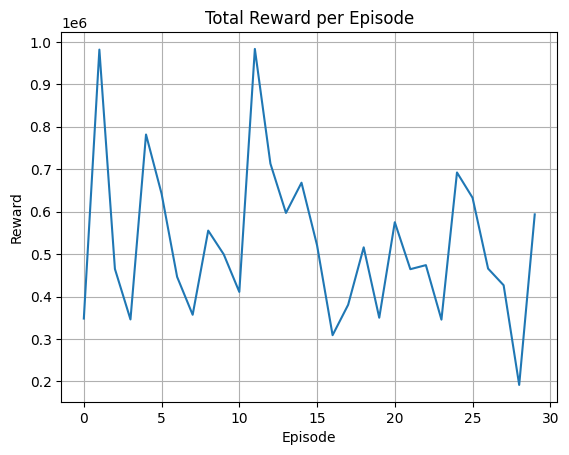

In [10]:
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Experiment 2

In [16]:
from sklearn.metrics import roc_auc_score

In [12]:
df = pd.read_csv("apple_preprocessed_data.csv")
def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [13]:
df.head()

,Date,Close,High,Low,Open,Volume,RSI_14,MACD,MACD_Signal,MACD_Hist,Open_Growth,Close_Growth,High_Growth,Low_Growth,Volume_Growth,landmark,ground_truth
0,2/21/2014,16.445499,16.737307,16.425148,16.681575,278784800,-0.763206,-0.267362,-0.322387,0.112891,-0.000375,-0.011108,-0.004525,-0.008318,-0.088516,-,-
1,2/24/2014,16.517506,16.591711,16.356888,16.379744,288909600,-0.634889,-0.272844,-0.315635,0.074661,-0.018094,0.004378,-0.008699,-0.004156,0.036318,-,-
2,2/25/2014,16.345621,16.580757,16.312433,16.574809,231952000,-0.904322,-0.284770,-0.312778,0.027393,0.011909,-0.010406,-0.000660,-0.002718,-0.197147,-,-
3,2/26/2014,16.198149,16.437669,16.143356,16.394149,276217200,-1.120323,-0.300524,-0.313853,-0.020333,-0.010900,-0.009022,-0.008630,-0.010365,0.190838,-,-
4,2/27/2014,16.521269,16.556022,16.157448,16.191576,301882000,-0.531135,-0.298188,-0.314215,-0.011676,-0.012356,0.019948,0.007200,0.000873,0.092915,-,-


In [20]:
# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) > 1:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop

def train_agent(df, episodes=100, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 9
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        step_count = 0
        actions = []
        ground_truth = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
            elif label == 'v':
                ground_truth.append(1)
            else:
                ground_truth.append(0)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state
            step_count += 1

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f} - Final Asset: ${env.total_asset:.2f}")

        # Evaluation: Print and compare actions
        symbols = {0: '-', 1: 'v', 2: '^'}
        actions_str = [symbols[a] for a in actions[:len(ground_truth)]]
        print("Agent Actions vs Ground Truth:")
        print("A: ", ''.join(actions_str))
        print("G: ", ''.join(df.loc[:len(actions_str)-1, 'ground_truth'].fillna('-').values))

        bin_gt = [1 if x in [1, 2] else 0 for x in ground_truth]
        bin_pred = [1 if x in [1, 2] else 0 for x in actions[:len(ground_truth)]]
        try:
            auc = roc_auc_score(bin_gt, bin_pred)
            print(f"AUC (Buy/Sell vs Hold): {auc:.4f}")
        except:
            print("AUC could not be computed due to lack of class variation.")

    return agent, reward_history

In [21]:
# Train the agent
agent, rewards = train_agent(df, episodes=30)

Episode 1/30 - Total Reward: 0.41 - Epsilon: 0.995 - Final Asset: $35609.66
Agent Actions vs Ground Truth:
A:  ^-v^--v^^-^^--^-v^^v-^vvvv^^^^v^vvvv-^-^^^^^v-^-v-^^-v^^-^vv^^v-^^-^^v--^--v^-vv^vvvv^-^^vv^vv--^vv--^-^v-v^v--v^-v^vv-^vvvv-^vvvv-v^-v^-^-^----^v--^^^-^^^vv^^vv--v^-v^-^^^--^--^^^v-v-^-^v--^v-^--^vvv^^-v^v^^v^-v^^-v^^^^--v-vv^v-^^-^--^-v^----vvv--vv-v--v--v^v^vvv--^-v^v^-^vvv^^v--v^v^---v^v-^^^-----v^vv---^-v^^-v-^-^^^-^^vv--v^--^vv-vvvv^--^v--v^v^^v---vvv^v-v--^--vvv--^v^v^^^vv--^v^^-^v-^-vvv^-^v----^---^-vv--^^^v---^^-v^^^-vv--v-^-v--vv^^vv^v^^^v^-v--^-^---v^-v-^^---^v^-^-v-^-vv^vv-v----v^vv--^^^v-^v^-^v---vvvvvv---^^-vvv-v^^^--v---v--^vv^^v--vv-v^^^vv-v^^^^-vv^v-----^---^^v-v^vvv---^v-vvv-v-vv^v^^v--v-v^-v^^-v----^-vv--^v--^-^v-^^--vv--^v^-^^^v^-v^-^-vv^vv^vvv-^^^^-^-vv-vv-^v--^v^^^---^---v^v---^-vv^-v-^--^v^--^-v^---^^-v^vvv^--^--^-v^^---vv^--^v--^--^-v-^^v^^--^-^-^vvv--v-^-v-^-v-^-^^-v--v-v-v^^^^-^v-v-^^^v-v-v----v---^-v-^^v^vvvv-^-vv-v^vv-^v^v-^^v-vv--^-v-vv-v^^v^--v-v^

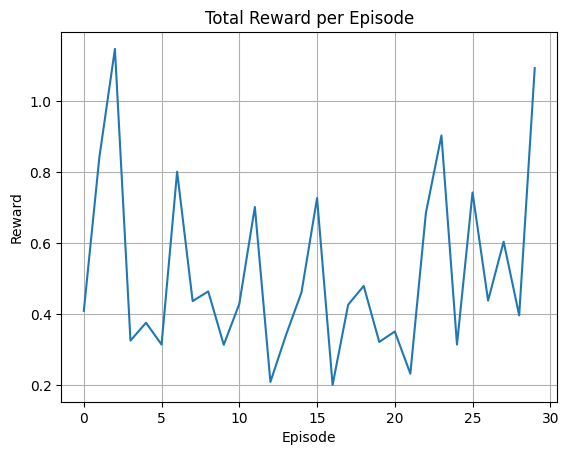

In [22]:
# Plot results
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Experiment 3

In [23]:
df = pd.read_csv("apple_preprocessed_data.csv")
def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [25]:
# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) > 1:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop

def train_agent(df, episodes=100, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 9
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        step_count = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state
            step_count += 1

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f} - Final Asset: ${env.total_asset:.2f}")

        # Evaluation: Print and compare actions
        symbols = {0: '-', 1: 'v', 2: '^'}
        actions_str = [symbols[a] for a in actions[:len(ground_truth)]]
        print("Agent Actions vs Ground Truth:")
        print("A: ", ''.join(actions_str))
        print("G: ", ''.join(df.loc[:len(actions_str)-1, 'ground_truth'].fillna('-').values))

        # Filter to only valid ground truth rows (^ or v)
        filtered_gt = [gt for gt, mask in zip(ground_truth, eval_mask) if mask]
        filtered_pred = [a for a, mask in zip(actions, eval_mask) if mask]
        bin_gt = [1 if x == 2 else 0 for x in filtered_gt]  # 1 = sell (^), 0 = buy (v)
        bin_pred = [1 if x == 2 else 0 for x in filtered_pred]

        try:
            auc = roc_auc_score(bin_gt, bin_pred)
            print(f"AUC (Sell vs Buy on ^/v only): {auc:.4f}")
        except:
            print("AUC could not be computed due to lack of class variation.")

    return agent, reward_history

In [26]:
# Train the agent
agent, rewards = train_agent(df, episodes=30)

Episode 1/30 - Total Reward: 0.42 - Epsilon: 0.995 - Final Asset: $34228.38
Agent Actions vs Ground Truth:
A:  v-vv^----^^^-vv---v^^-^^v-^v^^-vv--^-^-v----^-v-^^vv^-v^vvvv^v^v-^^-^^^^-v-vv^---vv--^---v^^-vvv-v-^vvv--v-^v^^^^^-^^-v^vvvv^^-^-^^v-v---^-^v-v^^-^-v^^v-^^-vv-v^^vv^-vv--vv----^^-^v^v-^vv^--v^^^^v^v-v^^-v^vv-^vv-v^--^^^--v^-^-^^^v^-^vvv-v^vvv^vvvvv--^vvv^v^^^--vv-v^^-^v---^^^-v^v^---^vv^--^-v--^vv^-^^v-^^v^v^---v-v-v--v^--v-vvv^^--vv-vv^^---v-v----^vvvv-^-^^-^v^--v----v-^---^--^^--^v^^^-v--^^^vvv-^---v^-v^^--vvv--^-^^^^-v--v-vv^-^v^-v^^v-v--vv^--v----^^v^^-^^-^-vv-^--^----vv^-^vvv^-^^^^v--vv^--^vv-v-^^vvv^-^^^v--^^---v^-^v^vvv--^^^-^-v^v^^^--^vvv^-v-v^vv-^--^^v-v--v-v--vv^--^--^--^v-v^vv^-vvv^vv--v^vvv-^vvvvv-^^v^v--^--vv-v-^v^^-v---^--v^-^vv-v^-vv^^v^------^^--v^v^^^^^-vv^vv-vv^v-^^^vv--^^v--v-vv--v^vvv^-^-v^v-^--^-vv^v--vv-------^vvv-vv^v^^v--^-v^^-vv^vv-^^-^v-^^^-^v-v-^-^vvv-v^^v^-^vvv-^v^v---^-^-^vv-^^^vvv^-^v-^--^-^v-^^v^vv--^vv^--^v-vvvvv-v^^^^-^--^v-^--vv---v^v^v^v^--^-

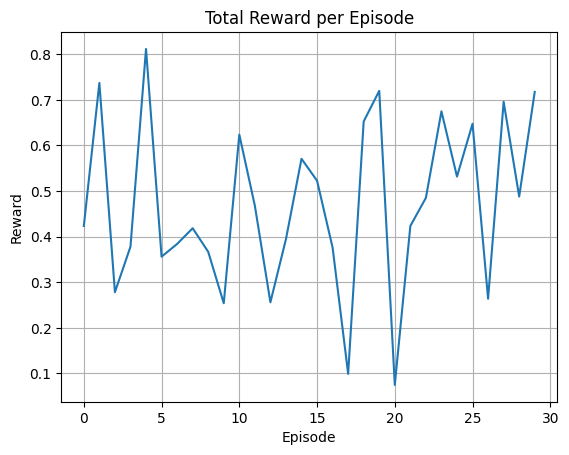

In [27]:
# Plot results
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Experiment 4
## to include a risk penalty based on the portfolio's exposure ratio (short term 1 days ago)

In [29]:
# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) > 1:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        # Add risk penalty for large exposure
        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)  # penalize excessive leverage  # small penalty for holding

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop

def train_agent(df, episodes=100, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 9
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        step_count = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state
            step_count += 1

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f} - Final Asset: ${env.total_asset:.2f}")

        # Evaluation: Print and compare actions
        symbols = {0: '-', 1: 'v', 2: '^'}
        actions_str = [symbols[a] for a in actions[:len(ground_truth)]]
        # print("Agent Actions vs Ground Truth:")
        # print("A: ", ''.join(actions_str))
        # print("G: ", ''.join(df.loc[:len(actions_str)-1, 'ground_truth'].fillna('-').values))

        # Filter to only valid ground truth rows (^ or v)
        filtered_gt = [gt for gt, mask in zip(ground_truth, eval_mask) if mask]
        filtered_pred = [a for a, mask in zip(actions, eval_mask) if mask]
        bin_gt = [1 if x == 2 else 0 for x in filtered_gt]  # 1 = sell (^), 0 = buy (v)
        bin_pred = [1 if x == 2 else 0 for x in filtered_pred]

        try:
            auc = roc_auc_score(bin_gt, bin_pred)
            print(f"AUC (Sell vs Buy on ^/v only): {auc:.4f}")
        except:
            print("AUC could not be computed due to lack of class variation.")

    return agent, reward_history


In [32]:
# Train the agent
agent, rewards = train_agent(df, episodes=100)

Episode 1/100 - Total Reward: -8.17 - Epsilon: 0.995 - Final Asset: $34826.95
AUC (Sell vs Buy on ^/v only): 0.4721
Episode 2/100 - Total Reward: -7.85 - Epsilon: 0.990 - Final Asset: $30497.78
AUC (Sell vs Buy on ^/v only): 0.5132
Episode 3/100 - Total Reward: -7.51 - Epsilon: 0.985 - Final Asset: $36018.87
AUC (Sell vs Buy on ^/v only): 0.4965
Episode 4/100 - Total Reward: -7.34 - Epsilon: 0.980 - Final Asset: $46989.33
AUC (Sell vs Buy on ^/v only): 0.5218
Episode 5/100 - Total Reward: -8.25 - Epsilon: 0.975 - Final Asset: $30044.60
AUC (Sell vs Buy on ^/v only): 0.4683
Episode 6/100 - Total Reward: -7.44 - Epsilon: 0.970 - Final Asset: $48810.07
AUC (Sell vs Buy on ^/v only): 0.5034
Episode 7/100 - Total Reward: -7.63 - Epsilon: 0.966 - Final Asset: $38902.73
AUC (Sell vs Buy on ^/v only): 0.5074
Episode 8/100 - Total Reward: -7.86 - Epsilon: 0.961 - Final Asset: $39339.18
AUC (Sell vs Buy on ^/v only): 0.5181
Episode 9/100 - Total Reward: -7.91 - Epsilon: 0.956 - Final Asset: $231

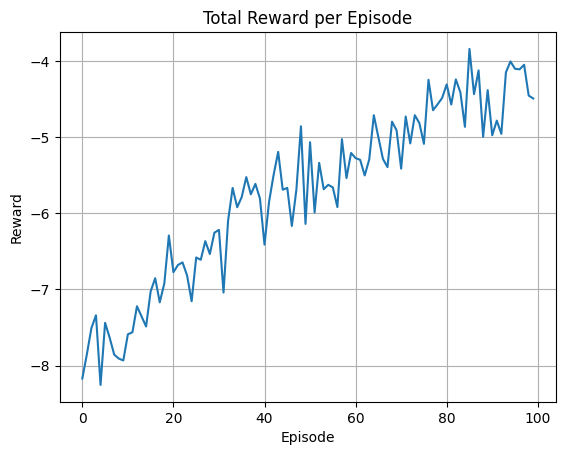

In [33]:
# Plot results
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Experiment 5
## to include a risk penalty based on the portfolio's exposure ratio (1 month ago)

In [34]:
# Load and normalize data
df = pd.read_csv("apple_preprocessed_data.csv")
def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [67]:
# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['Open', 'Close', 'High', 'Low', 'Volume']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) >= 2:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        # Add risk penalty for large exposure
        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(5)
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop

def train_agent(df, episodes=100, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 5
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []
    auc_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        step_count = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state
            step_count += 1

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f} - Final Asset: ${env.total_asset:.2f}")

        # Compute AUC for this episode
        filtered_gt = [gt for gt, mask in zip(ground_truth, eval_mask) if mask]
        filtered_pred = [a for a, mask in zip(actions, eval_mask) if mask]
        bin_gt = [1 if x == 2 else 0 for x in filtered_gt]  # 1 = sell (^), 0 = buy (v)
        bin_pred = [1 if x == 2 else 0 for x in filtered_pred]
        try:
            auc_val = roc_auc_score(bin_gt, bin_pred)
            auc_history.append(auc_val)
            print(f"AUC (Sell vs Buy on ^/v only): {auc_val:.4f}")
        except:
            auc_history.append(None)
            print("AUC could not be computed due to lack of class variation.")

    return agent, reward_history, auc_history


In [68]:
# Train the agent
agent, rewards, aucs = train_agent(df, episodes=100)

Episode 1/100 - Total Reward: -8.04 - Epsilon: 0.995 - Final Asset: $24746.63
AUC (Sell vs Buy on ^/v only): 0.5122
Episode 2/100 - Total Reward: -7.85 - Epsilon: 0.990 - Final Asset: $39310.46
AUC (Sell vs Buy on ^/v only): 0.4880
Episode 3/100 - Total Reward: -8.01 - Epsilon: 0.985 - Final Asset: $25136.53
AUC (Sell vs Buy on ^/v only): 0.5105
Episode 4/100 - Total Reward: -7.77 - Epsilon: 0.980 - Final Asset: $23190.00
AUC (Sell vs Buy on ^/v only): 0.4965
Episode 5/100 - Total Reward: -7.93 - Epsilon: 0.975 - Final Asset: $36861.85
AUC (Sell vs Buy on ^/v only): 0.4915
Episode 6/100 - Total Reward: -7.61 - Epsilon: 0.970 - Final Asset: $30148.70
AUC (Sell vs Buy on ^/v only): 0.4890
Episode 7/100 - Total Reward: -8.49 - Epsilon: 0.966 - Final Asset: $17275.55
AUC (Sell vs Buy on ^/v only): 0.5068
Episode 8/100 - Total Reward: -7.95 - Epsilon: 0.961 - Final Asset: $39941.63
AUC (Sell vs Buy on ^/v only): 0.4955
Episode 9/100 - Total Reward: -8.28 - Epsilon: 0.956 - Final Asset: $267

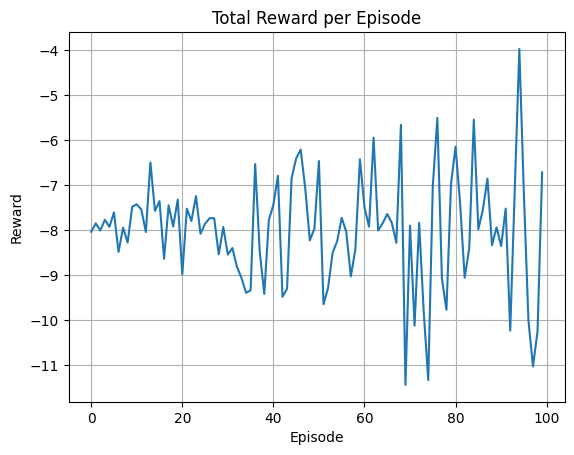

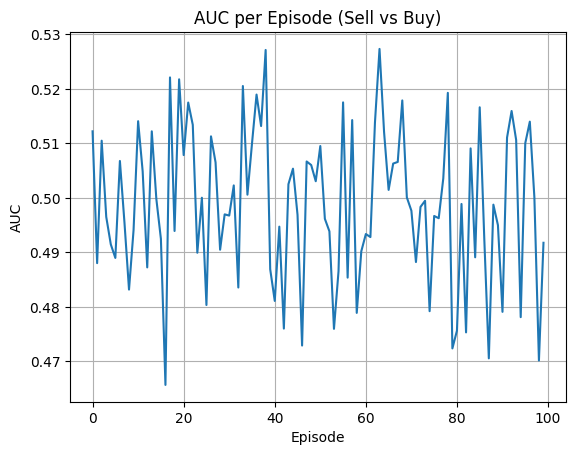

In [69]:
# Plot results
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Plot AUC curve
plt.plot([i for i, a in enumerate(aucs) if a is not None], [a for a in aucs if a is not None])
plt.title("AUC per Episode (Sell vs Buy)")
plt.xlabel("Episode")
plt.ylabel("AUC")
plt.grid(True)
plt.show()

# Experiment Reward 3 with 9 features normalized long term

In [ ]:
# Load and normalize data
df = pd.read_csv("apple_preprocessed_data.csv")
def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) >= 21:
            moving_avg = np.mean(list(self.history)[-21:])
            log_return = np.log(self.total_asset / (moving_avg + 1e-6))

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        # Add risk penalty for large exposure
        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# Training Loop

def train_agent(df, episodes=100, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 9
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []
    auc_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        step_count = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state
            step_count += 1

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        print(f"Episode {episode+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {epsilon:.3f} - Final Asset: ${env.total_asset:.2f}")

        # Compute AUC for this episode
        filtered_gt = [gt for gt, mask in zip(ground_truth, eval_mask) if mask]
        filtered_pred = [a for a, mask in zip(actions, eval_mask) if mask]
        bin_gt = [1 if x == 2 else 0 for x in filtered_gt]  # 1 = sell (^), 0 = buy (v)
        bin_pred = [1 if x == 2 else 0 for x in filtered_pred]
        try:
            auc_val = roc_auc_score(bin_gt, bin_pred)
            auc_history.append(auc_val)
            print(f"AUC (Sell vs Buy on ^/v only): {auc_val:.4f}")
        except:
            auc_history.append(None)
            print("AUC could not be computed due to lack of class variation.")

    return agent, reward_history, auc_history

Episode 1/100 - Total Reward: 4.06 - Epsilon: 0.995 - Final Asset: $40204.80
AUC (Sell vs Buy on ^/v only): 0.5129
Episode 2/100 - Total Reward: 0.27 - Epsilon: 0.990 - Final Asset: $27184.45
AUC (Sell vs Buy on ^/v only): 0.5012
Episode 3/100 - Total Reward: 4.80 - Epsilon: 0.985 - Final Asset: $43382.74
AUC (Sell vs Buy on ^/v only): 0.4952
Episode 4/100 - Total Reward: 3.13 - Epsilon: 0.980 - Final Asset: $34180.71
AUC (Sell vs Buy on ^/v only): 0.5235
Episode 5/100 - Total Reward: 2.72 - Epsilon: 0.975 - Final Asset: $32794.16
AUC (Sell vs Buy on ^/v only): 0.4889
Episode 6/100 - Total Reward: 3.16 - Epsilon: 0.970 - Final Asset: $35330.97
AUC (Sell vs Buy on ^/v only): 0.4918
Episode 7/100 - Total Reward: 7.55 - Epsilon: 0.966 - Final Asset: $53584.92
AUC (Sell vs Buy on ^/v only): 0.4677
Episode 8/100 - Total Reward: 1.48 - Epsilon: 0.961 - Final Asset: $28148.85
AUC (Sell vs Buy on ^/v only): 0.5115
Episode 9/100 - Total Reward: 6.53 - Epsilon: 0.956 - Final Asset: $51028.30
AUC

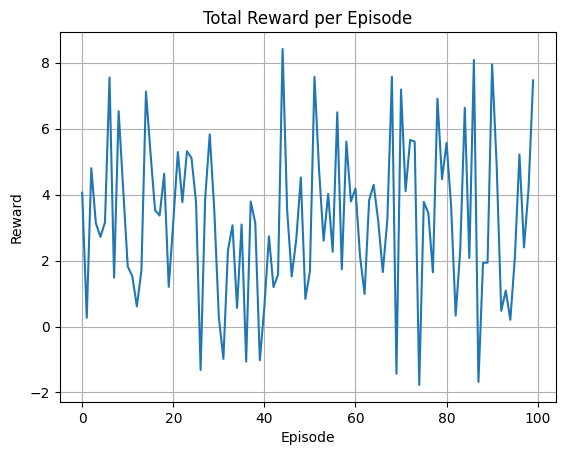

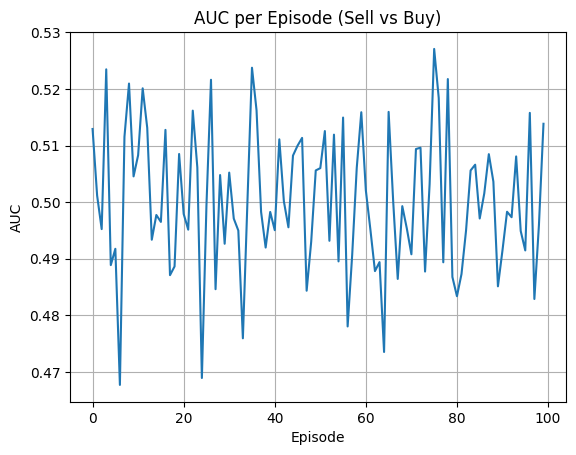

In [72]:
# Train the agent
agent, rewards, aucs = train_agent(df, episodes=100)

# Plot reward curve
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Plot AUC curve
plt.plot([i for i, a in enumerate(aucs) if a is not None], [a for a in aucs if a is not None])
plt.title("AUC per Episode (Sell vs Buy)")
plt.xlabel("Episode")
plt.ylabel("AUC")
plt.grid(True)
plt.show()